## Imports

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_config
from src.utils.data import (
    get_train_images_dir,
    get_test_images_dir,
    get_annotations_path,
    load_annotations,
    remove_duplicate_annotations
)
from src.processing.masks import build_masks

PROJECT_ROOT = get_project_root()
CONFIG = load_config()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation


## Load data

In [2]:
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_data_dir"]

TRAIN_IMAGES_DIR = get_train_images_dir(RAW_DATA_DIR)
TEST_IMAGES_DIR = get_test_images_dir(RAW_DATA_DIR)
ANNOTATIONS_PATH = get_annotations_path(RAW_DATA_DIR)

annotations = load_annotations(ANNOTATIONS_PATH)

In [3]:
annotations_clean = remove_duplicate_annotations(annotations)

print(f"Images: {len(annotations_clean['images']):,}")
print(f"Annotations: {len(annotations_clean['annotations']):,}")

Images: 707
Annotations: 5,209


## Build masks

In [ ]:
train_masks = build_masks(annotations_clean)

In [5]:
file_name = next(iter(train_masks))

print(file_name)
print(len(train_masks[file_name]))
print(train_masks[file_name][0].shape)

20140609195854Bh.jpeg
12
(2048, 2048)


In [8]:
file_name = random.choice(list(train_masks.keys()))

mask = train_masks[file_name][0]

print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


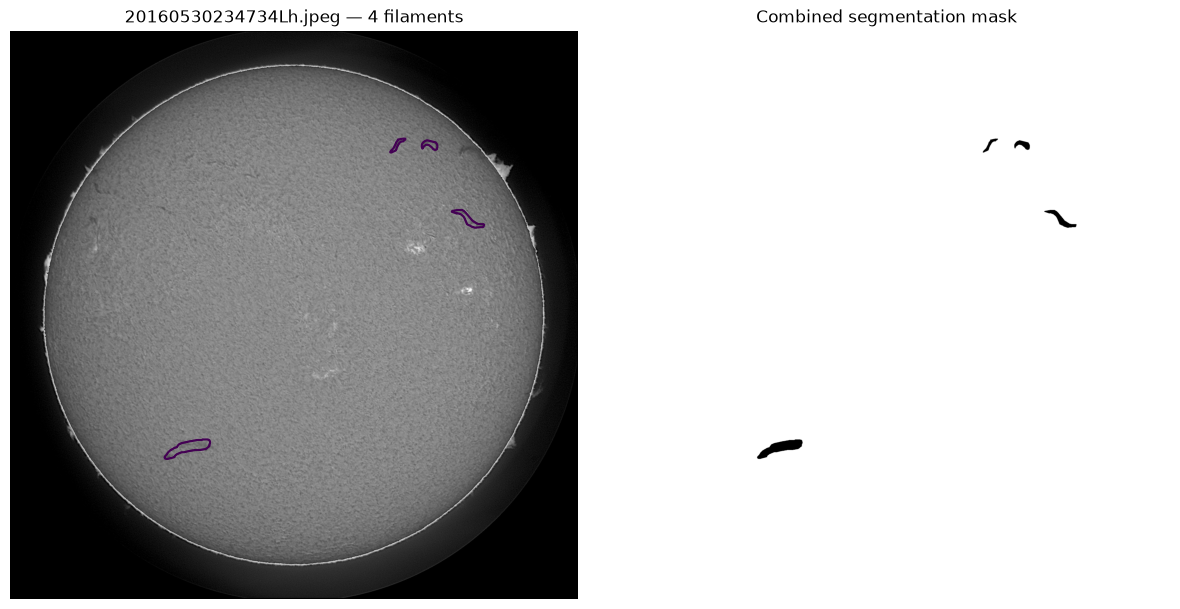

In [7]:
# Seleccionar una imagen aleatoria
file_name = random.choice(list(train_masks.keys()))

# Cargar imagen
image = np.array(
    Image.open(TRAIN_IMAGES_DIR / file_name)
)

# Obtener máscaras de la imagen
masks = train_masks[file_name]

# Combinar todas las máscaras
combined_mask = np.any(
    np.stack(masks),
    axis=0
)


# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original + contornos
axes[0].imshow(image, cmap="gray")

for mask in masks:
    axes[0].contour(
        mask,
        levels=[0.5],
        linewidths=1.5,
    )

axes[0].set_title(
    f"{file_name} — {len(masks)} filaments"
)
axes[0].axis("off")


# Máscara binaria
axes[1].imshow(
    combined_mask,
    cmap="gray_r",
    vmin=0,
    vmax=1,
)

axes[1].set_title("Combined segmentation mask")
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [9]:
foreground_ratios = []

for file_name, masks in train_masks.items():

    # Combinar todos los filamentos de la imagen
    combined_mask = np.any(
        np.stack(masks),
        axis=0,
    )

    # Porcentaje de píxeles pertenecientes a filamentos
    foreground_ratio = combined_mask.mean()

    foreground_ratios.append({
        "file_name": file_name,
        "foreground_pixels": int(combined_mask.sum()),
        "foreground_ratio": foreground_ratio,
        "foreground_percentage": foreground_ratio * 100,
    })

foreground_df = pd.DataFrame(foreground_ratios)

foreground_df.head()

,file_name,foreground_pixels,foreground_ratio,foreground_percentage
0,20140609195854Bh.jpeg,18170,0.004332,0.433207
1,20111116063134Lh.jpeg,31659,0.007548,0.754809
2,20130725122934Ch.jpeg,26412,0.006297,0.629711
3,20141027025054Uh.jpeg,41715,0.009946,0.994563
4,20160714235434Lh.jpeg,20300,0.004840,0.483990


In [10]:
foreground_df["foreground_percentage"].describe()

count    707.000000
mean       0.381328
std        0.290472
min        0.010014
25%        0.143421
50%        0.333905
75%        0.550008
max        1.710892
Name: foreground_percentage, dtype: float64

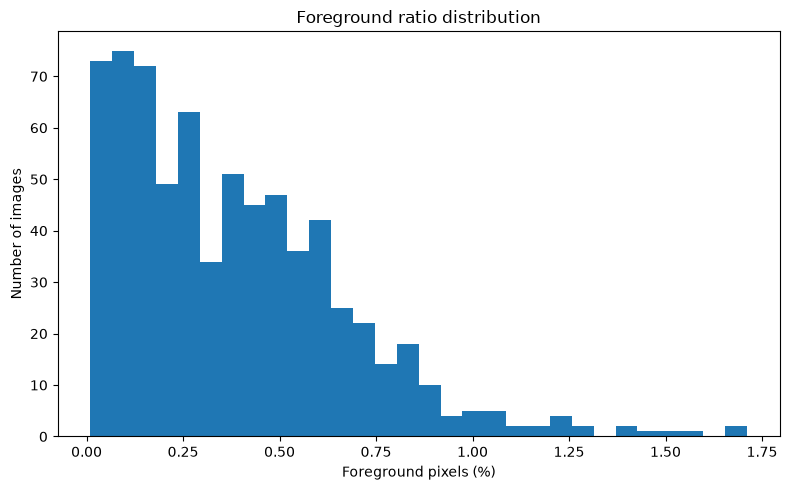

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    foreground_df["foreground_percentage"],
    bins=30,
)

ax.set_xlabel("Foreground pixels (%)")
ax.set_ylabel("Number of images")
ax.set_title("Foreground ratio distribution")

plt.tight_layout()
plt.show()

### Foreground ratio

The segmented filaments occupy a relatively small fraction of each image, with a mean foreground ratio of **0.38%** and a median of **0.33%**. However, the variability across images is considerable, ranging from **0.01% to 1.71%**.

This confirms a strong **class imbalance** between filament and background pixels. Therefore, using a standard binary cross-entropy loss alone may cause the model to favor the background class.